# Space Invaders con aprendizaje por refuerzo

In [1]:
from pathlib import Path
import sys
import json
import dataclasses

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Video
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ / "scripts"))

from si_rl.envs import DEFAULT_CONFIG, describe_env, make_single_env, make_raw_env, make_vector_env
from si_rl.baselines import RandomPolicy, RuleBasedPolicy
from si_rl.evaluate import evaluate, evaluate_vectorized, record_episode
from si_rl.networks import QNetwork
from si_rl.train_dqn import TrainConfig, train
from si_rl.policies import load_agent

import analisis_informe
import figuras_informe

## Entorno

In [2]:
describe_env()

{'env_id': 'ALE/SpaceInvaders-v5',
 'gymnasium': '1.3.0',
 'ale_py': '0.12.1',
 'numpy': '2.5.3',
 'observation_space': 'Box(0, 255, (210, 160, 3), uint8)',
 'action_space': 'Discrete(6)',
 'action_meanings': ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE'],
 'spec_kwargs': {'game': 'space_invaders',
  'repeat_action_probability': 0.25,
  'full_action_space': False,
  'frameskip': 4,
  'max_num_frames_per_episode': 108000},
 'sticky_action_prob': 0.25,
 'preprocessed_obs_shape': (4, 84, 84)}

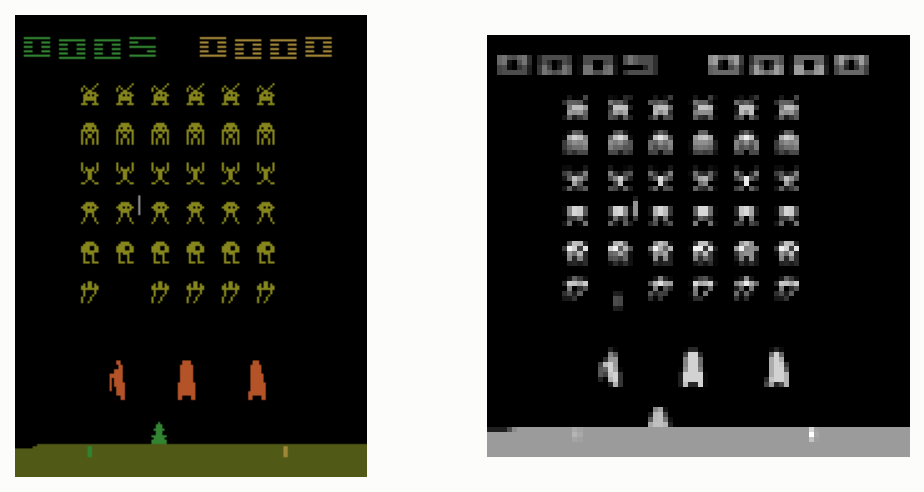

In [3]:
env = make_single_env(DEFAULT_CONFIG)
obs, _ = env.reset(seed=0)
for _ in range(90):
    obs, _, _, _, _ = env.step(env.action_space.sample())
crudo = env.unwrapped.ale.getScreenRGB()
env.close()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(crudo)
axs[1].imshow(np.asarray(obs)[-1], cmap="gray")
axs[0].axis("off")
axs[1].axis("off")
ruta_muestra = RAIZ / "reports" / "figures" / "informe" / "muestra_entorno.png"
fig.savefig(ruta_muestra, dpi=150, bbox_inches="tight")
plt.close(fig)
Image(filename=str(ruta_muestra))

In [4]:
(RAIZ / "reports" / "informe").mkdir(parents=True, exist_ok=True)
senal = analisis_informe.senal_aleatoria(40)
(RAIZ / "reports" / "informe" / "senal_aleatoria.json").write_text(
    json.dumps(senal), encoding="utf-8")
{"episodios": senal["episodios"], "valores": senal["valores"],
 "fraccion_pasos_con_recompensa": round(senal["fraccion_pasos_con_recompensa"], 4)}

{'episodios': 40,
 'valores': {5: 89, 10: 77, 15: 69, 20: 60, 25: 49, 30: 36, 200: 2},
 'fraccion_pasos_con_recompensa': 0.0184}

In [5]:
aleatorio = json.loads((RAIZ / "reports" / "etapa0_baseline_aleatorio.json").read_text(encoding="utf-8"))
regla = json.loads((RAIZ / "reports" / "etapa0_baseline_regla_simple.json").read_text(encoding="utf-8"))
pd.DataFrame([aleatorio["summary"], regla["summary"]])

,label,n_episodes,mean,median,std,min,max,p90,expected_best_of_5,metadata
0,aleatorio,30,157.7,122.5,118.8,15.0,515.0,243.5,308.6,{'env_config': {'env_id': 'ALE/SpaceInvaders-v...
1,regla_simple,30,272.2,237.5,96.5,180.0,540.0,367.5,395.2,{'env_config': {'env_id': 'ALE/SpaceInvaders-v...


In [6]:
rendimiento = json.loads((RAIZ / "reports" / "etapa0_check_env.json").read_text(encoding="utf-8"))
rendimiento["throughput_steps_por_segundo"]

{'16': 10857.6, '32': 14412.2, '64': 14457.2, '96': 15565.2}

In [7]:
cfg_det = dataclasses.replace(DEFAULT_CONFIG, repeat_action_probability=0.0, noop_max=0)
vec = make_vector_env(cfg_det, num_envs=1, episodic_life=False, reward_clipping=False)
single = make_single_env(cfg_det)
obs_vec, _ = vec.reset(seed=123)
obs_single, _ = single.reset(seed=123)

rng = np.random.default_rng(0)
acciones = rng.integers(0, cfg_det.n_actions, size=300)
comparados = iguales = 0
for a in acciones:
    ov, rv, tv, uv, _ = vec.step(np.array([a]))
    os_, rs, ts, us, _ = single.step(int(a))
    comparados += 1
    iguales += int(np.array_equal(ov[0], os_))
    if tv[0] or ts:
        break
vec.close()
single.close()
{"comparados": comparados, "identicos": iguales}

{'comparados': 300, 'identicos': 300}

## Metodología

In [8]:
red = QNetwork(in_channels=4, n_actions=6, dueling=True)
sum(p.numel() for p in red.parameters())

3293863

In [9]:
champion_json = json.loads((RAIZ / "checkpoints" / "champion.json").read_text(encoding="utf-8"))
champion_json["train_config"]

{'exp_id': 'E07_champion',
 'seed': 0,
 'total_steps': 50000000,
 'num_envs': 64,
 'algo': 'dqn',
 'double_dqn': True,
 'dueling': True,
 'per': False,
 'iqn_n': 8,
 'iqn_n_prime': 8,
 'iqn_k': 32,
 'iqn_n_cos': 64,
 'iqn_kappa': 1.0,
 'buffer_size': 750000,
 'learning_starts': 80000,
 'batch_size': 512,
 'n_step': 3,
 'per_alpha': 0.5,
 'per_beta_start': 0.4,
 'per_beta_end': 1.0,
 'lr': 0.00025,
 'adam_eps': 0.00015,
 'gamma': 0.99,
 'target_update_interval': 40000,
 'max_grad_norm': 10.0,
 'updates_per_step': 1,
 'eps_start': 1.0,
 'eps_end': 0.01,
 'eps_decay_steps': 1000000,
 'eval_epsilon': 0.001,
 'log_interval': 20000,
 'eval_interval': 500000,
 'eval_episodes': 50,
 'eval_envs': 32,
 'checkpoint_interval': 2000000,
 'device': 'cuda',
 'amp': False,
 'prefetch': True}

## Entrenamiento

In [10]:
def entrenar_o_cargar(cfg, env_cfg=DEFAULT_CONFIG):
    run_dir = RAIZ / "runs" / f"{cfg.exp_id}_seed{cfg.seed}"
    ya_existe = (run_dir / "config.json").exists()
    if not ya_existe:
        train(cfg, env_cfg)
    return run_dir, ya_existe


def historial(exp_id, tag, seed=0):
    run_dir = RAIZ / "runs" / f"{exp_id}_seed{seed}"
    acc = EventAccumulator(str(run_dir / "tensorboard"), size_guidance={"scalars": 0})
    acc.Reload()
    if tag not in acc.Tags()["scalars"]:
        return np.array([]), np.array([])
    puntos = acc.Scalars(tag)
    return np.array([p.step for p in puntos]), np.array([p.value for p in puntos])

Línea base DQN

In [11]:
cfg_e01 = TrainConfig(exp_id="E01_dqn", seed=0, total_steps=10_000_000, buffer_size=500_000,
                     learning_starts=80_000, batch_size=512, lr=2.5e-4,
                     eval_interval=500_000, eval_episodes=10)
entrenar_o_cargar(cfg_e01)

(WindowsPath('C:/Users/fabim/OneDrive/Desktop/UVG/Semestre8/DeepLearning/Proyecto2/runs/E01_dqn_seed0'),
 True)

Ablaciones aditivas sobre double dqn, dueling, retornos de tres pasos y repetición priorizada

In [12]:
ablaciones = {
    "E02_double": dict(double_dqn=True),
    "E03_dueling": dict(double_dqn=True, dueling=True),
    "E04_nstep": dict(double_dqn=True, dueling=True, n_step=3),
    "E05_per": dict(double_dqn=True, dueling=True, n_step=3, per=True),
}
for exp_id, overrides in ablaciones.items():
    cfg = TrainConfig(exp_id=exp_id, seed=0, total_steps=4_000_000, buffer_size=500_000,
                      lr=2.5e-4, **overrides)
    print(exp_id, entrenar_o_cargar(cfg))

E02_double (WindowsPath('C:/Users/fabim/OneDrive/Desktop/UVG/Semestre8/DeepLearning/Proyecto2/runs/E02_double_seed0'), True)
E03_dueling (WindowsPath('C:/Users/fabim/OneDrive/Desktop/UVG/Semestre8/DeepLearning/Proyecto2/runs/E03_dueling_seed0'), True)
E04_nstep (WindowsPath('C:/Users/fabim/OneDrive/Desktop/UVG/Semestre8/DeepLearning/Proyecto2/runs/E04_nstep_seed0'), True)
E05_per (WindowsPath('C:/Users/fabim/OneDrive/Desktop/UVG/Semestre8/DeepLearning/Proyecto2/runs/E05_per_seed0'), True)


IQN sobre la misma configuración

In [13]:
cfg_e06 = TrainConfig(exp_id="E06_iqn", seed=0, algo="iqn", double_dqn=True, dueling=True,
                     n_step=3, total_steps=50_000_000, buffer_size=500_000, lr=1e-4,
                     eps_decay_steps=1_000_000, eval_interval=500_000, eval_episodes=50)
entrenar_o_cargar(cfg_e06)

(WindowsPath('C:/Users/fabim/OneDrive/Desktop/UVG/Semestre8/DeepLearning/Proyecto2/runs/E06_iqn_seed0'),
 True)

In [14]:
tabla_ablaciones = pd.read_csv(RAIZ / "reports" / "comparacion_step_4000000.csv")
tabla_ablaciones.sort_values("E_max_de_5", ascending=False)

,experimento,algo,double,dueling,n_step,per,steps,media,mediana,desv,p90,max,E_max_de_5
0,E04_nstep_seed0,dqn,True,True,3,False,4000000,904.5,977.5,342.4,1348.5,1670.0,1302.6
1,E05_per_seed0,dqn,True,True,3,True,4000000,752.9,602.5,214.5,1034.5,1475.0,1029.5
2,E03_dueling_seed0,dqn,True,True,1,False,4000000,612.0,587.5,138.4,791.0,1050.0,775.2
3,E06_iqn_seed0,iqn,True,True,3,False,4000000,578.4,552.5,138.7,740.0,1540.0,731.4
4,E01_dqn_seed0,dqn,False,False,1,False,4000000,494.1,542.5,181.0,696.5,1040.0,686.8
5,E02_double_seed0,dqn,True,False,1,False,4000000,534.2,542.5,132.8,691.0,970.0,676.0


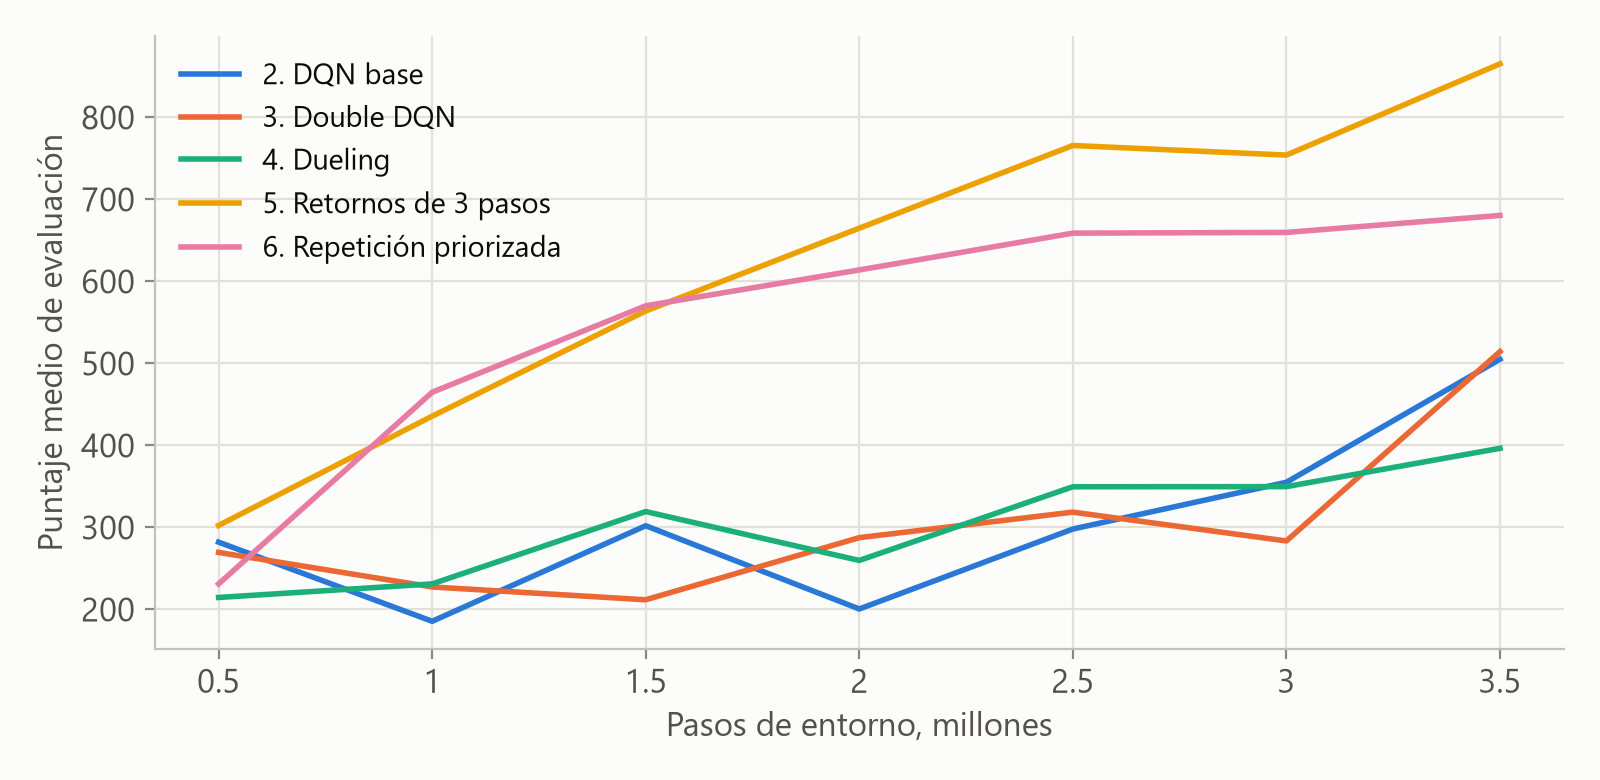

In [15]:
Image(filename=str(RAIZ / "reports" / "figures" / "informe" / "figura_10.png"))

Política de evaluación, épsilon voraz frente a un residuo de exploración

In [16]:
eps_e04 = json.loads((RAIZ / "reports" / "sweep_epsilon_final.json").read_text(encoding="utf-8"))
pd.DataFrame(eps_e04["resultados"])

,epsilon,media,mediana,desv,p90,max,E_max_de_5,p10_max_de_5
0,0.000,871.3,747.5,359.4,1297.5,1860.0,1308.5,1060.0
1,0.001,920.8,975.0,373.0,1266.0,1875.0,1364.7,1100.0
2,0.010,928.6,960.0,373.5,1385.0,1810.0,1384.0,1105.0
3,0.050,804.5,602.5,321.9,1230.5,1640.0,1209.3,970.0


Distorsiones de riesgo sobre IQN, sin reentrenar

In [17]:
riesgo = pd.read_csv(RAIZ / "reports" / "sweep_risk_mejor.csv")
riesgo.sort_values("E_max_de_5", ascending=False)

,distorsion,eta,media,desv,p90,max,E_max_de_5
0,pow,1.00,1032.1,378.9,1451.5,2030.0,1473.0
1,cvar,0.50,998.5,368.6,1416.0,2110.0,1426.8
2,neutral,0.00,910.0,345.9,1394.5,1965.0,1336.6
3,cvar_sup,0.75,868.8,360.1,1400.0,2060.0,1331.3
4,cvar_sup,0.50,849.5,340.0,1386.0,1825.0,1279.7
5,wang,0.75,802.5,326.4,1375.0,1775.0,1230.6
6,cvar_sup,0.25,773.7,304.8,1230.0,1975.0,1172.0


Configuracion ganadora entrenada durante cincuenta millones de pasos

In [18]:
cfg_e07 = TrainConfig(exp_id="E07_champion", seed=0, double_dqn=True, dueling=True, n_step=3,
                     total_steps=50_000_000, buffer_size=750_000, lr=2.5e-4,
                     eps_decay_steps=1_000_000, eval_interval=500_000, eval_episodes=50,
                     checkpoint_interval=2_000_000)
entrenar_o_cargar(cfg_e07)

(WindowsPath('C:/Users/fabim/OneDrive/Desktop/UVG/Semestre8/DeepLearning/Proyecto2/runs/E07_champion_seed0'),
 True)

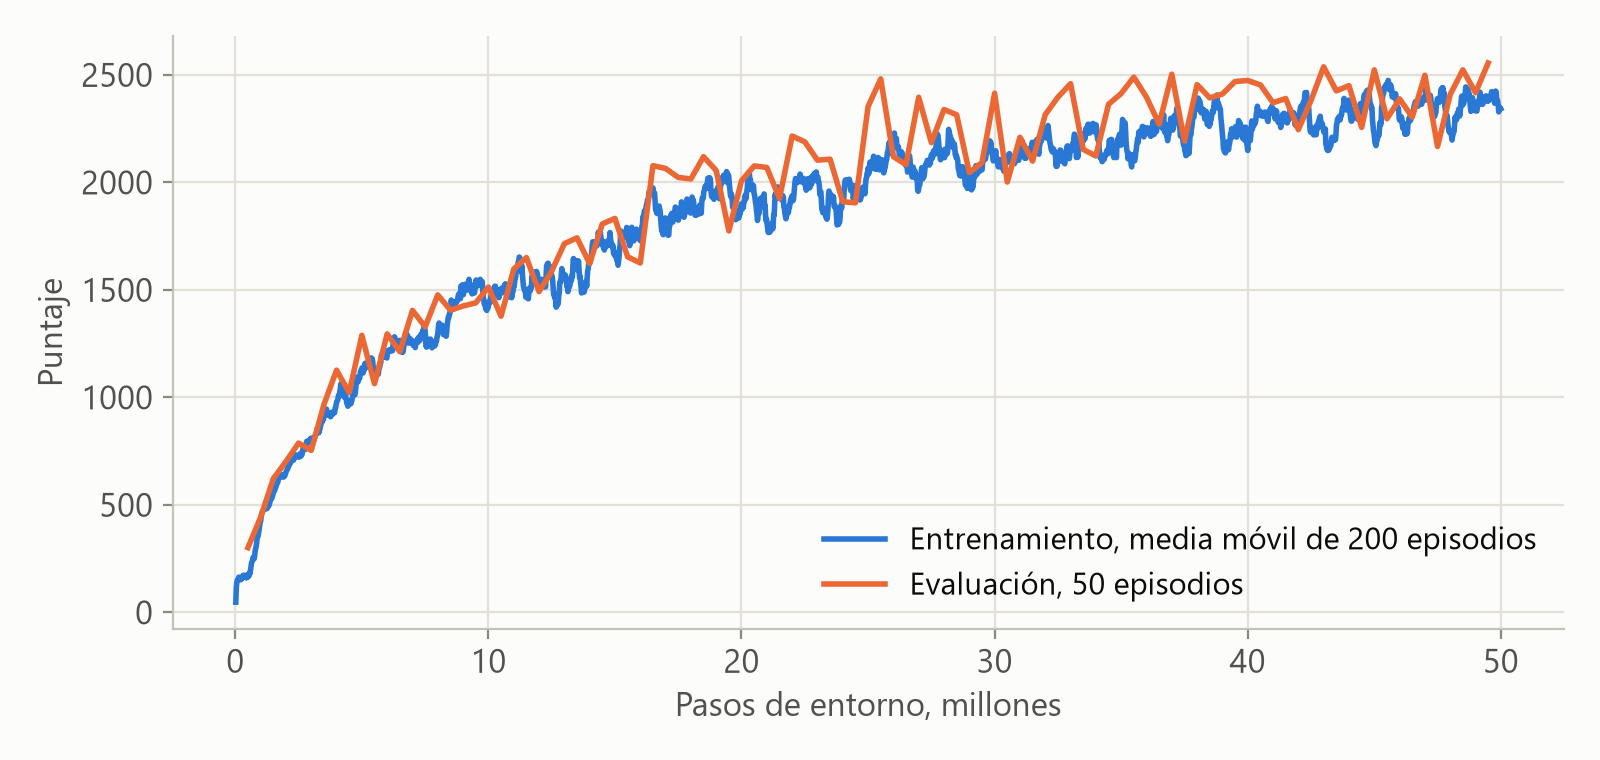

In [19]:
Image(filename=str(RAIZ / "reports" / "figures" / "informe" / "figura_16.png"))

Recorte de recompensa y horizonte de descuento, dos hipótesis puestas a prueba

In [20]:
cfg_e08 = TrainConfig(exp_id="E08_hreward", seed=0, double_dqn=True, dueling=True, n_step=3,
                     reward_transform="h", total_steps=20_000_000, buffer_size=500_000,
                     lr=2.5e-4, eval_interval=1_000_000, eval_episodes=50)
cfg_e09 = TrainConfig(exp_id="E09_gamma997", seed=0, double_dqn=True, dueling=True, n_step=3,
                     gamma=0.997, total_steps=20_000_000, buffer_size=750_000, lr=2.5e-4,
                     eval_interval=1_000_000, eval_episodes=50)
print(entrenar_o_cargar(cfg_e08))
print(entrenar_o_cargar(cfg_e09))

(WindowsPath('C:/Users/fabim/OneDrive/Desktop/UVG/Semestre8/DeepLearning/Proyecto2/runs/E08_hreward_seed0'), True)
(WindowsPath('C:/Users/fabim/OneDrive/Desktop/UVG/Semestre8/DeepLearning/Proyecto2/runs/E09_gamma997_seed0'), True)


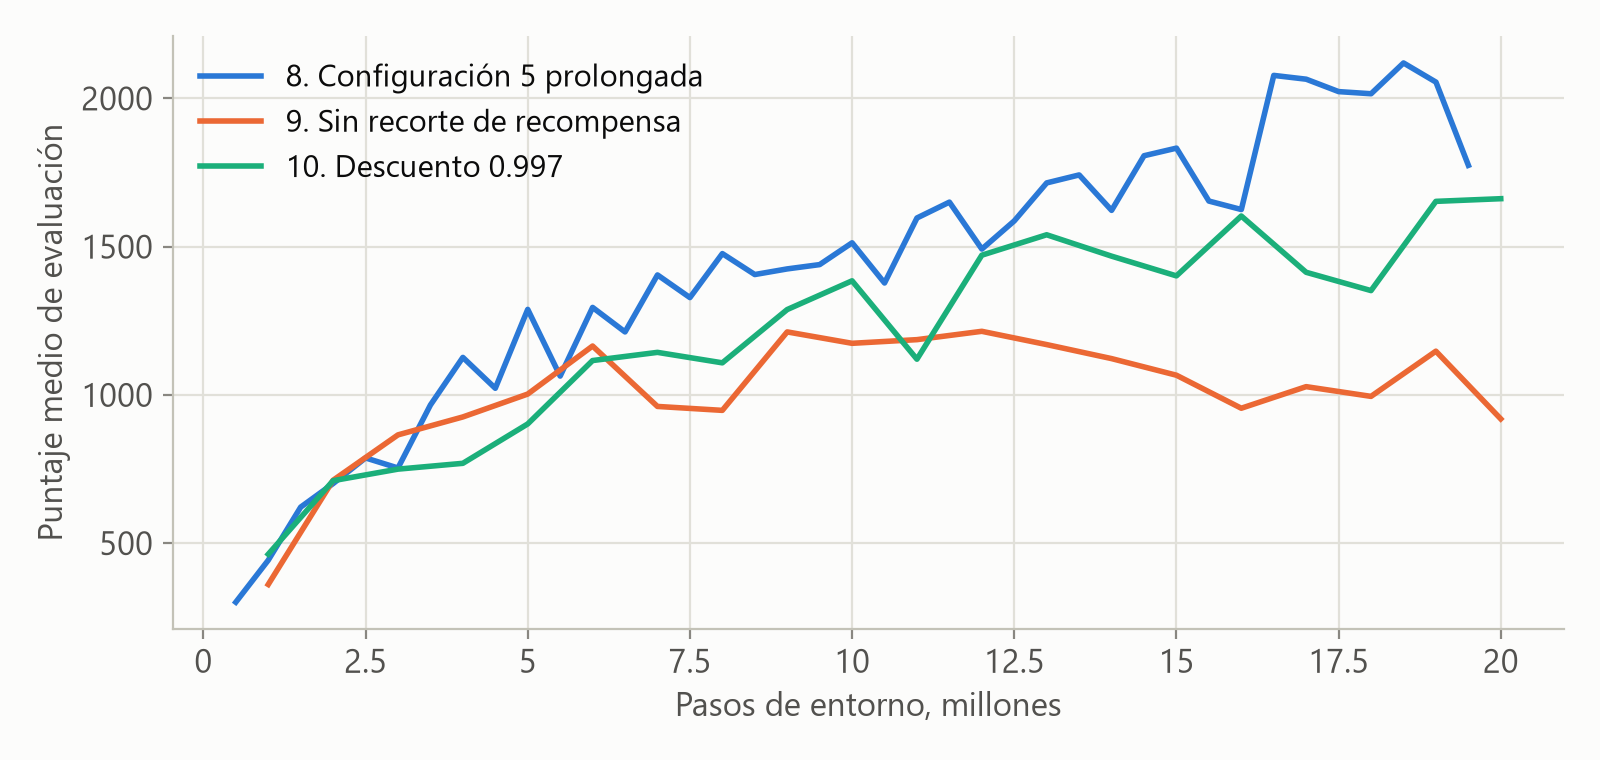

In [21]:
Image(filename=str(RAIZ / "reports" / "figures" / "informe" / "figura_17.png"))

Selección del punto de control con doscientos episodios por candidato

In [22]:
seleccion = pd.read_csv(RAIZ / "reports" / "seleccion_checkpoint_E07_champion_seed0.csv")
seleccion.sort_values("E_max_de_5", ascending=False)

,checkpoint,steps,media,mediana,desv,p90,max,E_max_de_5
0,step_34000000.pt,34000000,2133.8,2715.0,936.9,3015.0,3645.0,2964.4
1,step_32000000.pt,32000000,2273.9,2767.5,823.4,3015.0,3320.0,2942.0
2,step_36000000.pt,36000000,2360.8,2802.5,801.9,2962.0,3235.0,2938.0
3,step_42000000.pt,42000000,2444.2,2815.0,717.7,2940.0,3645.0,2937.4
4,step_50000000.pt,50000000,2563.1,2815.0,601.4,2963.0,3590.0,2921.2
5,final.pt,50000000,2563.1,2815.0,601.4,2963.0,3590.0,2921.2
6,step_40000000.pt,40000000,2451.4,2815.0,699.3,2823.0,3445.0,2913.5
7,step_28000000.pt,28000000,2223.8,2687.5,789.5,2960.0,3420.0,2910.0
8,step_46000000.pt,46000000,2385.5,2762.5,706.8,2917.0,3365.0,2903.2
9,step_48000000.pt,48000000,2368.3,2815.0,826.2,2905.0,3545.0,2903.1


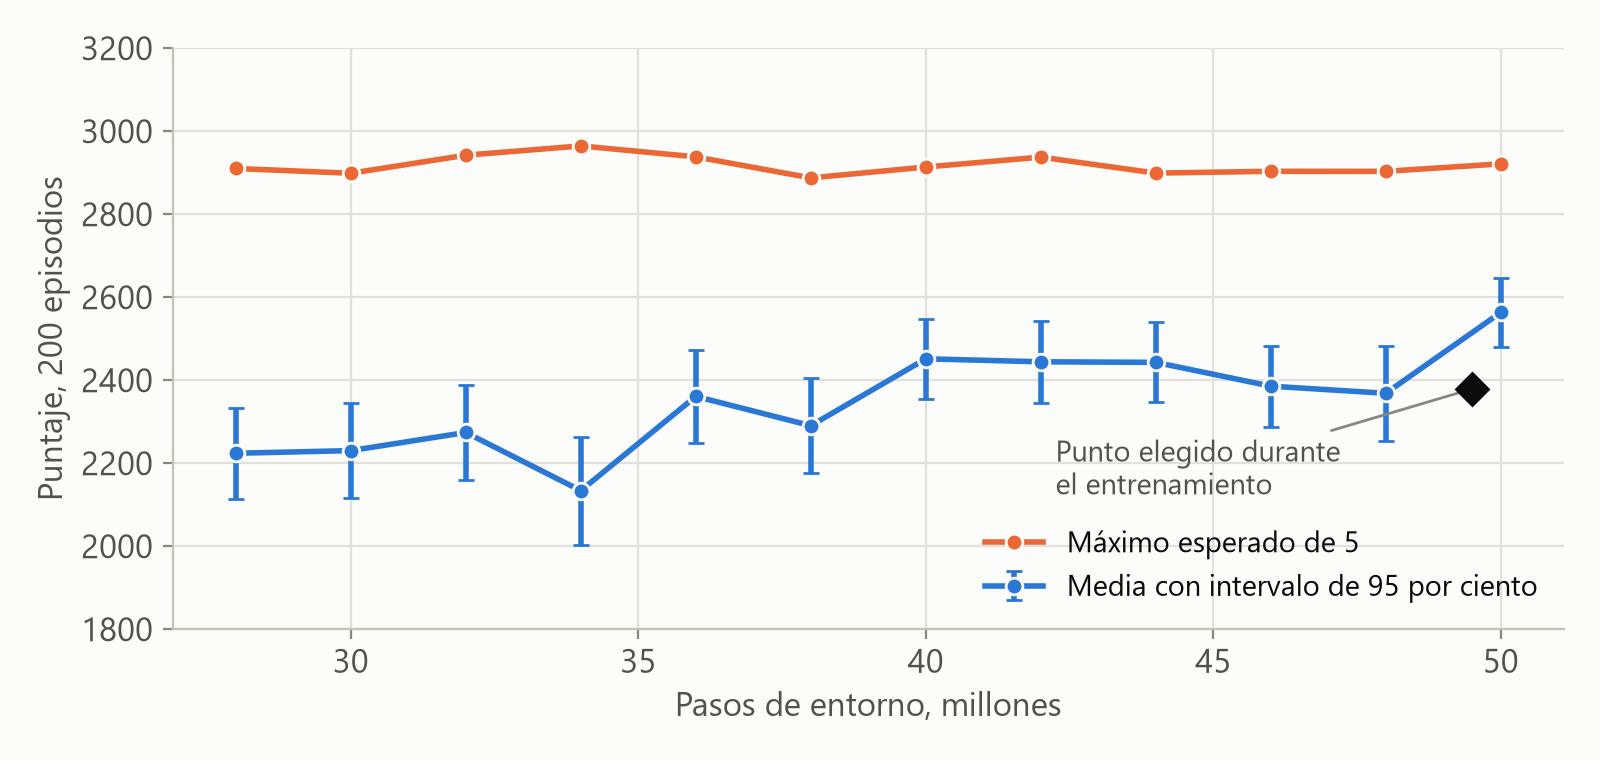

In [23]:
Image(filename=str(RAIZ / "reports" / "figures" / "informe" / "figura_18.png"))

## Comportamiento del agente campeón

In [24]:
comportamiento = analisis_informe.comportamiento_campeon(RAIZ / "checkpoints" / "champion.pt", 40)
(RAIZ / "reports" / "informe" / "comportamiento_campeon.json").write_text(
    json.dumps(comportamiento), encoding="utf-8")
{"acciones": comportamiento["acciones"], "episodios": len(comportamiento["finales"])}

  ep   0  puntaje= 3265.0  pasos= 2255  vidas al terminar=0


  ep   1  puntaje= 2790.0  pasos= 2159  vidas al terminar=0


  ep   2  puntaje= 2815.0  pasos= 2180  vidas al terminar=0


  ep   3  puntaje= 2815.0  pasos= 2159  vidas al terminar=0


  ep   4  puntaje= 2815.0  pasos= 1979  vidas al terminar=0


...

  ep  36  puntaje= 2815.0  pasos= 1931  vidas al terminar=0


  ep  37  puntaje= 2815.0  pasos= 2058  vidas al terminar=0


  ep  38  puntaje= 2820.0  pasos= 2046  vidas al terminar=0


  ep  39  puntaje= 2435.0  pasos= 2222  vidas al terminar=0


{'acciones': {0: 4833, 1: 37562, 2: 4414, 3: 3137, 4: 15090, 5: 12315},
 'episodios': 40}

In [25]:
figuras_informe.main()

  figura  1
  figura  2
  figura  3


  figura  4
  figura  5
  figura  6


  figura  7
  figura  8
  figura  9


  figura 10
  figura 11
  figura 12


  figura 13
  figura 14


  figura 15


  figura 16


  figura 17
  figura 18


  figura 19
  figura 20


  figura 21
  figura 22
{
  "fraccion_2815": 44.4,
  "corr_puntaje_duracion": 0.9098756448283932,
  "abatido": 13,
  "invasion": 27,
  "fotogramas_video": 9873,
  "acciones_por_ciento": [
    6.248141588344042,
    48.56045817119365,
    5.706454990885703,
    4.055539036340836,
    19.50847435715117,
    15.920931856084602
  ]
}


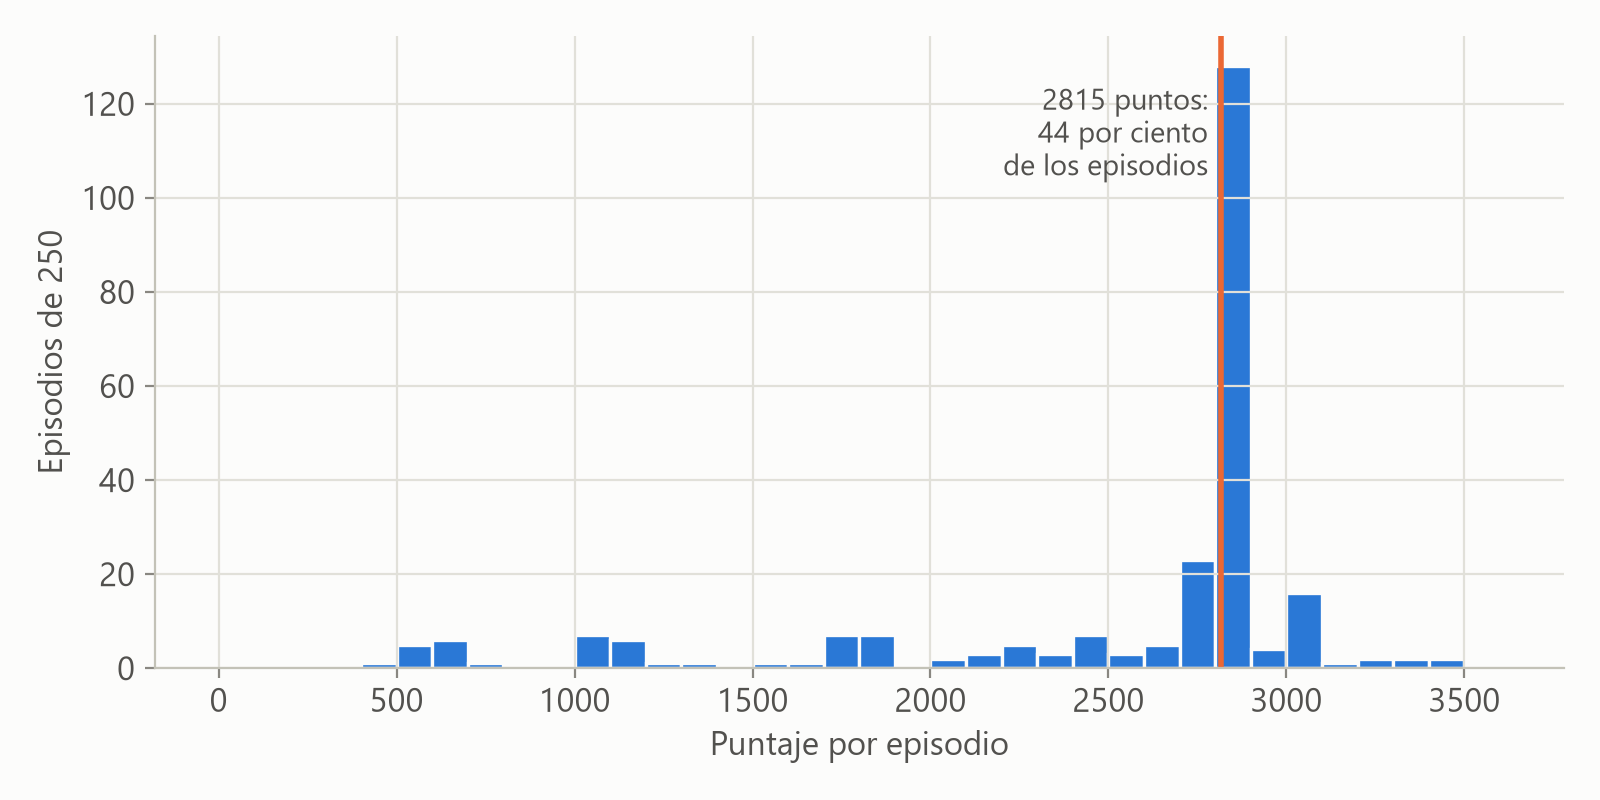

In [26]:
Image(filename=str(RAIZ / "reports" / "figures" / "informe" / "figura_19.png"))

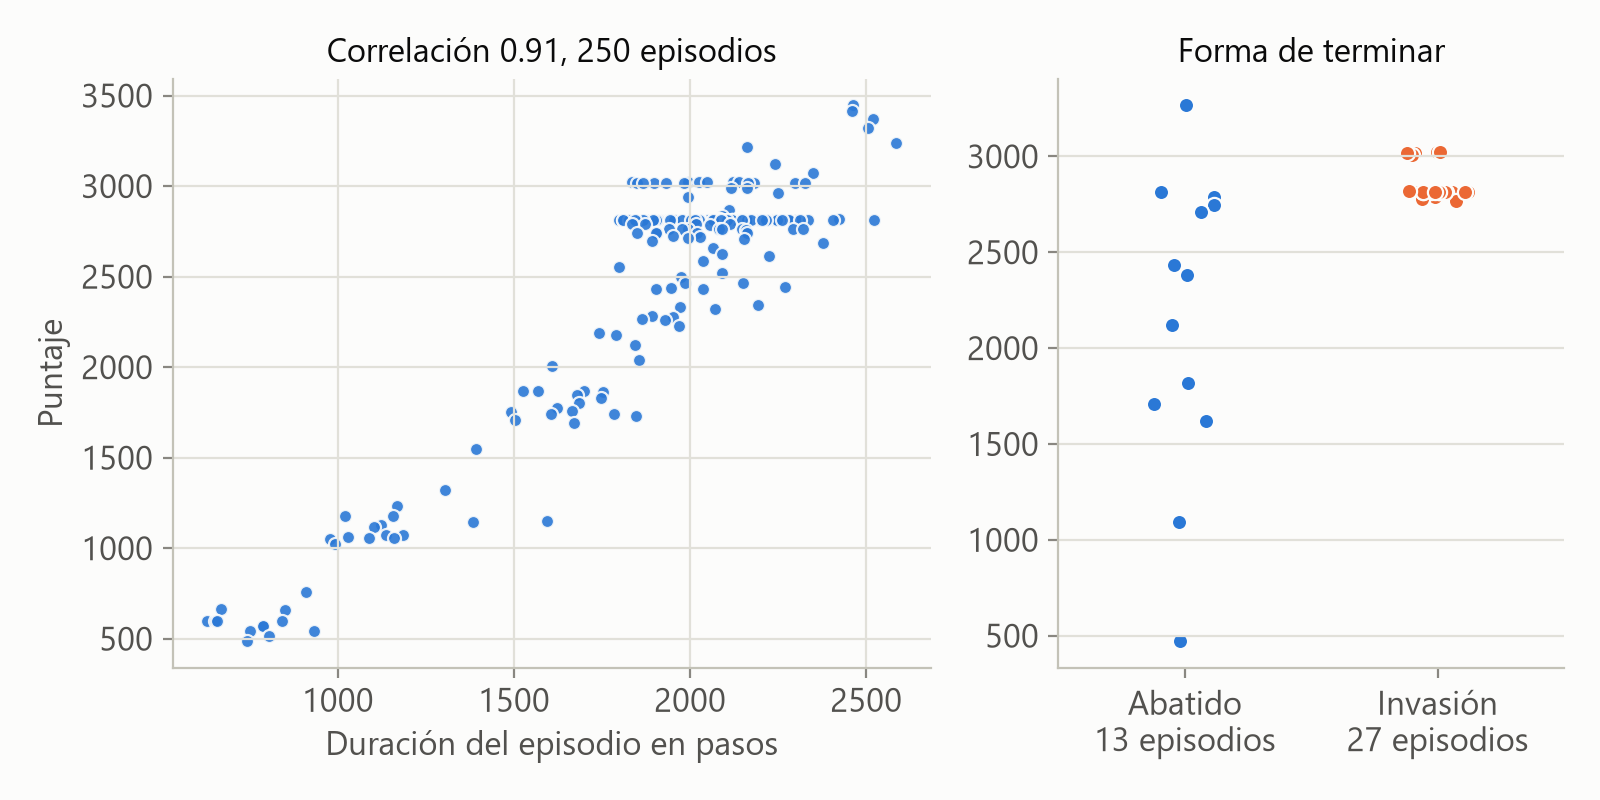

In [27]:
Image(filename=str(RAIZ / "reports" / "figures" / "informe" / "figura_20.png"))

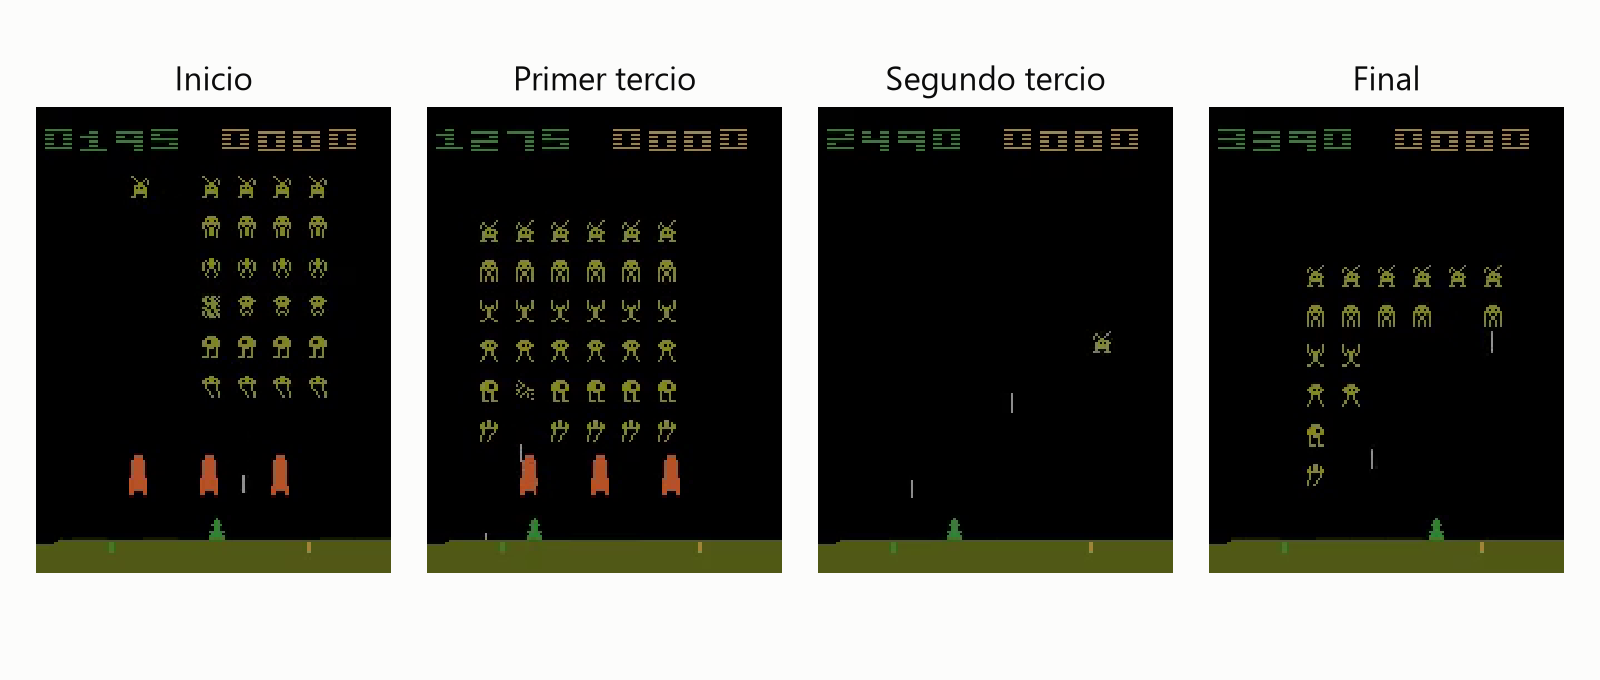

In [28]:
Image(filename=str(RAIZ / "reports" / "figures" / "informe" / "figura_21.png"))

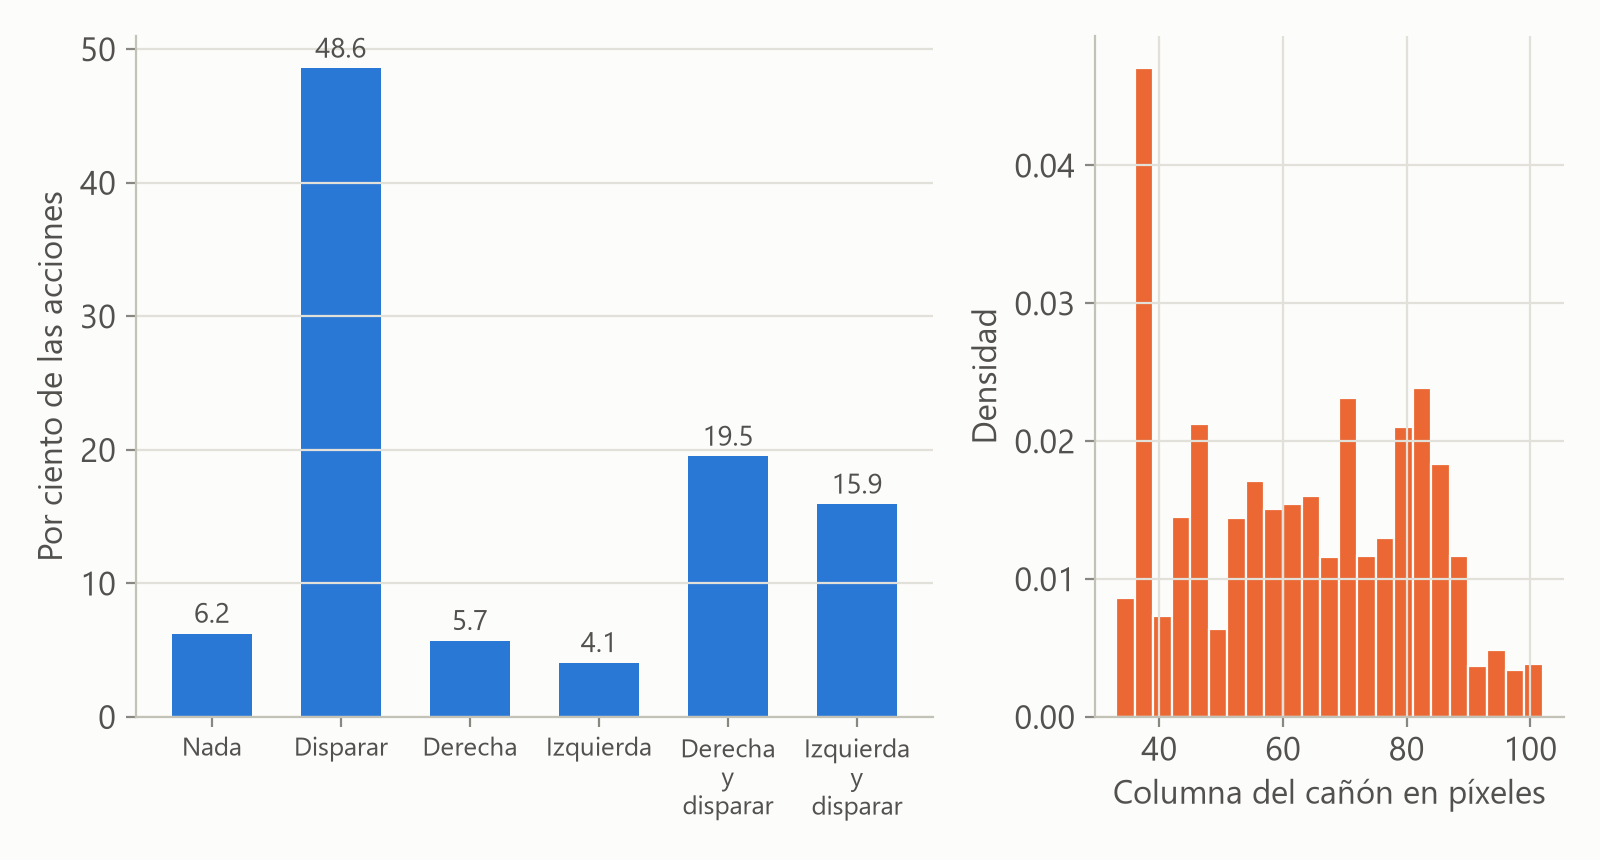

In [29]:
Image(filename=str(RAIZ / "reports" / "figures" / "informe" / "figura_22.png"))

## Desempeño final

In [30]:
leaderboard = pd.read_csv(RAIZ / "data" / "evaluation" / "leaderboard_champion.csv")
{"episodios": len(leaderboard), "media": round(leaderboard["score"].mean(), 1),
 "maximo": leaderboard["score"].max()}

{'episodios': 250, 'media': np.float64(2508.1), 'maximo': np.float64(3445.0)}

## Evaluación y video, protocolo exacto de la competencia

In [31]:
politica, env_cfg, meta = load_agent(RAIZ / "checkpoints" / "champion.pt", epsilon=0.0)
reporte = evaluate(lambda: make_single_env(env_cfg), politica, label="champion",
                   n_episodes=5, base_seed=1000)
reporte.summary()

  [champion] ep   1/5  score=  1070.0  steps=  1303   1.25s


  [champion] ep   2/5  score=  2790.0  steps=  1842   1.93s


  [champion] ep   3/5  score=  2815.0  steps=  1845   1.79s


  [champion] ep   4/5  score=  2815.0  steps=  2035   2.08s


  [champion] ep   5/5  score=  2815.0  steps=  1948   1.85s


{'label': 'champion',
 'n_episodes': 5,
 'mean': 2461.0,
 'median': 2815.0,
 'std': 695.6,
 'min': 1070.0,
 'max': 2815.0,
 'p90': 2815.0,
 'expected_best_of_5': 2813.7,
 'metadata': {}}

In [32]:
mejor_episodio = max(reporte.episodes, key=lambda e: e.score)
carpeta = RAIZ / "reports" / "videos" / "notebook_final"
resultado_video = record_episode(
    lambda: make_single_env(env_cfg, video_folder=str(carpeta), name_prefix="notebook_final"),
    politica, seed=mejor_episodio.seed)
resultado_video.score, resultado_video.steps

(2815.0, 1845)

In [33]:
ruta_video = sorted((carpeta).glob("*.mp4"))[-1]
Video(str(ruta_video), embed=True)

Código completo en https://github.com/FabianMoraeles/Proyecto2-SpaceInvaders-RL